In [1]:
####################### TRAINING DEEP NEURAL POLICY BASED MASKING POET ################################
from dataclasses import dataclass
import os
import torch
import torch.nn as nn
from torch.distributions import Categorical
from torch.utils.data import DataLoader
import random

# Importazioni dei tuoi moduli custom
from Configuration import PATH_CONFIGURATION, TRANSFORMER_CONFIGURATION, CLASSIFIER_CONFIGURATION, RL_CONFIGURATION
from Tokenizers.tokenizer import SyllableTokenizer, WordPieceTokenizer
from models.Transformers import PoetEmbedder
from models.RewardSystem import PoeticRewardSystem
from datasets.MaskedDatasetPoetry import DynamicMaskedPoetryDataset
from datasets.TrainingUtilsRL import EntropyScheduler, TrainingParameters, collect_trajectory, compute_trajectory_loss, apply_policy_optimization, build_episode_log, compute_trajectory_loss_baseline

# Inizializzazione variabili globali dai file di configurazione
EMBEDDING_DIM = TRANSFORMER_CONFIGURATION.PARAMETERS()["VECTOR_DIMENSION"] # type: ignore
CTX_LEN = TRANSFORMER_CONFIGURATION.PARAMETERS()["MAX_SEQ_LEN"] # type: ignore
BATCH_SIZE = RL_CONFIGURATION.TRAINING_PARAMETERS()["BATCH_SIZE"] # type: ignore
SEED = CLASSIFIER_CONFIGURATION.TRAINING_PARAMETERS()["SEED"] # type: ignore
LR_WORDPIECE = RL_CONFIGURATION.TRAINING_PARAMETERS()["LR_WORDPIECE"] # type: ignore
LR_SYLLABLE = RL_CONFIGURATION.TRAINING_PARAMETERS()["LR_SYLLABLE"] # type: ignore
MAX_STEPS_PER_EPISODE = RL_CONFIGURATION.TRAINING_PARAMETERS()["MAX_STEPS_PER_EPISODE"] # type: ignore
EPOCHS = RL_CONFIGURATION.TRAINING_PARAMETERS()["EPOCHS"] # type: ignore
GAMMA = RL_CONFIGURATION.TRAINING_PARAMETERS()["GAMMA"] # type: ignore
# Path per caricare i testi dal dataset (usiamo quelli in FAKE_POEMS o POETRY_DIR)
POEMS_DIR = PATH_CONFIGURATION.DATASETS_PATH()["POETRY"] # type: ignore
#MAX_CHUNKS = RL_CONFIGURATION.TRAINING_PARAMETERS()["MAX_CHUNKS"] # type: ignore
MAX_CHUNKS = RL_CONFIGURATION.TRAINING_PARAMETERS()["MAX_CHUNKS"] # type: ignore
SYLLABLE_TRANSFORMER_WEIGHTS_PATH = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_TRANSFORMER"] # type: ignore
WORDPIECE_TRANSFORMER_WEIGHTS_PATH = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_TRANSFORMER"] # type: ignore
CUTOFF_WORDPIECE_THRESHOLD = RL_CONFIGURATION.TRAINING_PARAMETERS()["CUTOFF_WORDPIECE_THRESHOLD"] # type: ignore
CUTOFF_SYLLABLE_THRESHOLD = RL_CONFIGURATION.TRAINING_PARAMETERS()["CUTOFF_SYLLABLE_THRESHOLD"] # type: ignore
TOP_K = RL_CONFIGURATION.TRAINING_PARAMETERS()["TOP_K"] # type: ignore
random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SYL_LAYERS = CLASSIFIER_CONFIGURATION.PARAMETERS()["SYLLABLE_LAYERS"] # type: ignore
WP_LAYERS = CLASSIFIER_CONFIGURATION.PARAMETERS()["WORDPIECE_LAYERS"] # type: ignore

training_params = TrainingParameters(
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    max_chunks_per_training=MAX_CHUNKS,
    epochs=EPOCHS,
    lr_wordpiece=LR_WORDPIECE,
    lr_syllable=LR_SYLLABLE,
    gamma=GAMMA,
    batch_size_rl=BATCH_SIZE,
    cutoff_threshold_word=CUTOFF_WORDPIECE_THRESHOLD,
    cutoff_threshold_syllable=CUTOFF_SYLLABLE_THRESHOLD,
    top_k=TOP_K,
    log_interval=10
)

print(f"[INFO] Pipeline RL inizializzata su device: {device}")

[INFO] Pipeline RL inizializzata su device: cuda


In [2]:
################## MODELS INITIALIZATION ##################

from Tokenizers.tokenizer import BasePoetryTokenizer


print("[INFO] Inizializzazione Tokenizer...")
syl_tokenizer = SyllableTokenizer.from_config()
word_tokenizer = WordPieceTokenizer.from_config()
print("[INFO] Inizializzazione e Caricamento Embedders...")
syl_embedder = PoetEmbedder.from_config(
    tokenizer=syl_tokenizer,
    WEIGHT_PATH=SYLLABLE_TRANSFORMER_WEIGHTS_PATH,
    device=device
).eval()

word_embedder = PoetEmbedder.from_config(
    tokenizer=word_tokenizer,
    WEIGHT_PATH=WORDPIECE_TRANSFORMER_WEIGHTS_PATH,
    device=device
).eval()

print("[INFO] Inizializzazione Poetic Reward System...")
reward_system = PoeticRewardSystem.from_config(
    syl_embedder=syl_embedder, 
    word_embedder=word_embedder, 
    device=device
)

print("[SUCCESS] Tutti i modelli di validazione sono stati caricati e messi in modalità EVAL!")
all_poems = BasePoetryTokenizer.get_all_poems_from_directory(POEMS_DIR)

[INFO] Inizializzazione Tokenizer...
[INFO] Inizializzazione e Caricamento Embedders...
[INFO] Caricato modello pre-addestrato da './weights/syllable_transformer_weights.pt'
[INFO] Caricato modello pre-addestrato da './weights/wordpiece_transformer_weights.pt'
[INFO] Inizializzazione Poetic Reward System...
[SUCCESS] Tutti i modelli di validazione sono stati caricati e messi in modalità EVAL!


In [3]:
import gc
import json
import os
from typing import Callable, Any

import torch
from datasets.TrainingUtilsRL import (
    EntropyScheduler, 
    RunningBaseline, 
    collect_trajectory, 
    compute_trajectory_loss, 
    build_episode_log
)
from models.MaskingPoetRL import ParallelMaskingPoets, ParallelMaskingPoetsEnv

RLLossFunction = Callable[..., tuple[torch.Tensor, torch.Tensor, Any]]


def train_rl_agent_batched(
    env: ParallelMaskingPoetsEnv,
    poets: ParallelMaskingPoets,
    rl_dataloader,
    device: torch.device,
    training_params,
    syl_weights_path: str,
    word_weights_path: str,
    return_function: RLLossFunction = compute_trajectory_loss,
    output_history_path: str = "logs/rl_history.json",
    save_checkpoint_interval: int = 500,
    use_amp: bool = True,  # Abilita Automatic Mixed Precision (float16/bfloat16)
):
    # --- 1. SETUP POLICIES ED OPTIMIZERS ---
    syl_policy = poets.syl_policy.to(device)
    word_policy = poets.word_policy.to(device)
    syl_policy.train()
    word_policy.train()
    
    syl_optimizer = torch.optim.AdamW(syl_policy.parameters(), lr=training_params.lr_syllable)
    word_optimizer = torch.optim.AdamW(word_policy.parameters(), lr=training_params.lr_wordpiece)

    scaler = torch.amp.grad_scaler.GradScaler(device.type, enabled=(use_amp and device.type == "cuda"))

    os.makedirs(os.path.dirname(output_history_path) or ".", exist_ok=True)

    # --- 2. GESTIONE LOG E PERSISTENZA (CARICAMENTO CRONOLOGIA) ---
    saved_global_step = 0
    if os.path.exists(output_history_path):
        try:
            with open(output_history_path, "r", encoding="utf-8") as f:
                training_history = json.load(f)
            saved_global_step = training_history.get("global_step", len(training_history.get("episodes", [])))
            print(f"[INFO] Cronologia caricata da '{output_history_path}' (Global Step ripreso: {saved_global_step}, Episodi totali: {len(training_history.get('episodes', []))}).")
        except Exception as e:
            print(f"[WARNING] Impossibile leggere log esistente: {e}. Nuovo file creato.")
            training_history = {"config": vars(training_params), "algorithm": "GPOMDP-Batched-Sequential", "episodes": [], "global_step": 0}
    else:
        training_history = {
            "config": vars(training_params),
            "algorithm": "GPOMDP-Batched-Sequential",
            "episodes": [],
            "global_step": 0,
        }

    # --- 3. CARICAMENTO DEI PESI DAL CHECKPOINT (SE ESISTONO) ---
    if syl_weights_path and os.path.exists(syl_weights_path):
        try:
            state = torch.load(syl_weights_path, map_location=device)
            syl_policy.load_state_dict(state.get("state_dict", state))
            print(f"[INFO] Pesi policy sillabica caricati con successo da '{syl_weights_path}'")
        except Exception as e:
            print(f"[WARNING] Errore nel caricamento dei pesi sillabici: {e}")

    if word_weights_path and os.path.exists(word_weights_path):
        try:
            state = torch.load(word_weights_path, map_location=device)
            word_policy.load_state_dict(state.get("state_dict", state))
            print(f"[INFO] Pesi policy wordpiece caricati con successo da '{word_weights_path}'")
        except Exception as e:
            print(f"[WARNING] Errore nel caricamento dei pesi wordpiece: {e}")

    # --- 4. SCHEDULER ED ENTROPY TRACKING ---
    episodes_per_epoch = len(rl_dataloader)
    total_train_steps = episodes_per_epoch * training_params.epochs

    baseline_tracker = RunningBaseline(decay=training_params.gamma)
    word_entropy_scheduler = EntropyScheduler(beta_start=0.04, beta_end=0.001, total_episodes=total_train_steps, decay_type="exponential")
    syl_entropy_scheduler = EntropyScheduler(beta_start=0.02, beta_end=0.001, total_episodes=total_train_steps, decay_type="exponential")
    accumulate_steps = max(1, training_params.batch_size_rl)

    # Calcolo automatico del punto di ripresa basato sul global_step salvato
    start_epoch = (saved_global_step // episodes_per_epoch) + 1 if episodes_per_epoch > 0 else 1
    skip_episodes = saved_global_step % episodes_per_epoch if episodes_per_epoch > 0 else 0

    print(f"[INFO] Avvio RL Training | Device: {device} | AMP: {use_amp} | "
          f"Grad Accumulation Steps: {accumulate_steps} | Total Steps: {total_train_steps} | "
          f"Ripresa da Epoca {start_epoch}, Batch Index: {skip_episodes} (Global Step: {saved_global_step})")

    if start_epoch > training_params.epochs:
        print(f"[INFO] L'addestramento risulta già completato in base alle epoche configurate ({training_params.epochs}). Aumenta le epoche in configurazione se vuoi continuare il fine-tuning.")

    # --- 5. LOOP PRINCIPALE ---
    syl_optimizer.zero_grad(set_to_none=True)
    word_optimizer.zero_grad(set_to_none=True)

    global_step = saved_global_step

    for epoch in range(start_epoch, training_params.epochs + 1):

        for episode_idx, batch in enumerate(rl_dataloader):
            if epoch == start_epoch and episode_idx < skip_episodes:
                continue

            beta_syl = syl_entropy_scheduler.get_beta(global_step)
            beta_word = word_entropy_scheduler.get_beta(global_step)

            # A. Rollout con Automatic Mixed Precision
            with torch.amp.autocast_mode.autocast(device_type=device.type, enabled=use_amp):
                traj = collect_trajectory(
                    env=env,
                    poets=poets,
                    batch=batch,
                    device=device,
                    max_steps_per_episode=training_params.max_steps_per_episode,
                    gamma=training_params.gamma,
                    word_tokenizer=poets.word_tok,
                    syl_tokenizer=poets.syl_tok,
                )

                # B. Calcolo Loss
                syl_loss, word_loss, update = return_function(
                    traj=traj,
                    gamma=training_params.gamma,
                    device=device,
                    beta_syl=beta_syl,
                    beta_word=beta_word,
                    global_baseline_syl=baseline_tracker.syl_mean if baseline_tracker.is_initialized else None,
                    global_baseline_word=baseline_tracker.word_mean if baseline_tracker.is_initialized else None,
                )

            # C. Aggiornamento baseline storica
            baseline_tracker.update(update.syl_returns, update.word_returns)

            # D. TRUE GRADIENT ACCUMULATION
            if traj.trajectory_len > 0:
                scaled_syl_loss = syl_loss / accumulate_steps
                scaled_word_loss = word_loss / accumulate_steps

                scaler.scale(scaled_syl_loss).backward(retain_graph=False)
                scaler.scale(scaled_word_loss).backward(retain_graph=False)

            # E. Step dell'ottimizzatore ogni batch_size_rl episodi
            is_last_episode = (episode_idx == episodes_per_epoch - 1)
            if (episode_idx + 1) % accumulate_steps == 0 or is_last_episode:
                scaler.step(syl_optimizer)
                scaler.step(word_optimizer)
                scaler.update()

                syl_optimizer.zero_grad(set_to_none=True)
                word_optimizer.zero_grad(set_to_none=True)

            # F. Telemetria e Debug
            score_diff_syl = traj.steps_data[-1]['syl_classifier_score'] - traj.steps_data[0]['syl_classifier_score']
            score_diff_word = traj.steps_data[-1]['word_classifier_score'] - traj.steps_data[0]['word_classifier_score']
            print(f"[DEBUG] Ep. {episode_idx}/{episodes_per_epoch} (Global Step: {global_step}) | "
                  f"Steps: {traj.trajectory_len} | β_syl: {beta_syl:.4f} | β_word: {beta_word:.4f} | "
                  f"Δ Score Syl: {score_diff_syl:.4f} | Δ Score Word: {score_diff_word:.4f}")

            # G. Append log e salvataggio stato globale
            training_history["episodes"].append(build_episode_log(traj, update, epoch, episode_idx))
            training_history["global_step"] = global_step
            training_history["last_beta_syl"] = beta_syl
            training_history["last_beta_word"] = beta_word

            # Incrementa il global step corrente
            global_step += 1

            # Rilascia le liste di tensori per liberare immediatamente la VRAM
            traj.final_syl_state = None
            traj.final_word_state = None
            del traj, update, syl_loss, word_loss

            # Checkpoint Intermedio
            if global_step > 0 and global_step % save_checkpoint_interval == 0:
                torch.save({"state_dict": poets.syl_policy.state_dict()}, syl_weights_path)
                torch.save({"state_dict": poets.word_policy.state_dict()}, word_weights_path)
                training_history["global_step"] = global_step
                with open(output_history_path, "w", encoding="utf-8") as f:
                    json.dump(training_history, f, indent=4, ensure_ascii=False)
                torch.cuda.empty_cache()
                print(f"[CHECKPOINT] Salvataggio pesi e log al global step {global_step} (Beta Word: {beta_word:.4f}).")

        # Fine Epoca
        training_history["global_step"] = global_step
        with open(output_history_path, "w", encoding="utf-8") as f:
            json.dump(training_history, f, indent=4, ensure_ascii=False)
        gc.collect()
        torch.cuda.empty_cache()

    # --- 6. SALVATAGGIO FINALE ---
    torch.save({"state_dict": poets.syl_policy.state_dict()}, syl_weights_path)
    torch.save({"state_dict": poets.word_policy.state_dict()}, word_weights_path)
    training_history["global_step"] = global_step
    with open(output_history_path, "w", encoding="utf-8") as f:
        json.dump(training_history, f, indent=4, ensure_ascii=False)

    print(f"[INFO] Training completato con successo. Pesi finali salvati.")
    return training_history

In [4]:
############## DATASET PREPARATION FOR RL TRAINING ##############
import numpy as np

from datasets.PoetryCorruptionUtils import CustomDistribution, UniformDistribution
from datasets.PoetryCorruptionUtils import WordAndSyllableCorruptionMethod, parallelized_corruption_generation

# ------------------ DISTRIBUZIONI MIRATE ------------------
# 1. End-Heavy: Pesa enormemente la fine dei chunk (zona rime e chiusure di verso)
end_heavy_dist = CustomDistribution(lambda x: x ** 3)

# 2. Start-Heavy: Pesa l'inizio dei versi/chunk (incipit ed anastrofi)
start_heavy_dist = CustomDistribution(lambda x: (1.0 - x) ** 3)

# 3. Center-Focused: Gaussiana centrata a 0.5 (struttura metrica interna)
center_dist = CustomDistribution(lambda x: np.exp(-12.0 * (x - 0.5) ** 2))

uni_dist = UniformDistribution()  # Distribuzione uniforme

# ------------------ CONFIGURAZIONI DATASET PER RL ------------------

# Bridge intermedio per il Curriculum Learning tra 0.1 e 0.4
medium_uniform_dataset_params = {
"name": "medium_uniform_corruption",
    "horizontal_distribution": uni_dist,
    "vertical_distribution": uni_dist,
    "syl_corruption_level": 0.05,  # Allineato
    "word_corruption_level": 0.05, # Allineato
    "syl_tokenizer": syl_tokenizer,
    "word_tokenizer": word_tokenizer,
    "poems_dir": POEMS_DIR,
    "ctx_len": CTX_LEN,
}

# Focalizzato sulle rime: addestra l'agente a ricostruire le uscite dei versi
rhymes_end_dataset_params = {
"name": "rhymes_end_focused_corruption",
    "horizontal_distribution": end_heavy_dist,
    "vertical_distribution": uni_dist,
    "syl_corruption_level": 0.10,
    "word_corruption_level": 0.10, # Mai a 0.0 in addestramento congiunto!
    "syl_tokenizer": syl_tokenizer,
    "word_tokenizer": word_tokenizer,
    "poems_dir": POEMS_DIR,
    "ctx_len": CTX_LEN,
}

# Focalizzato sugli incipit e aperture di strofa
incipit_dataset_params = {
    "name": "incipit_focused_corruption",
    "horizontal_distribution": start_heavy_dist,
    "vertical_distribution": uni_dist,
    "syl_corruption_level": 0.15,
    "word_corruption_level": 0.15,
    "syl_tokenizer": syl_tokenizer,
    "word_tokenizer": word_tokenizer,
    "poems_dir": POEMS_DIR,
    "ctx_len": CTX_LEN,
}

# Focalizzato sul corpo centrale del verso (ritmo e sillabazione interna)
center_rhythm_dataset_params = {
    "name": "center_rhythm_corruption",
    "horizontal_distribution": center_dist,
    "vertical_distribution": uni_dist,
    "syl_corruption_level": 0.20,
    "word_corruption_level": 0.20, # Mai a 0.0!
    "syl_tokenizer": syl_tokenizer,
    "word_tokenizer": word_tokenizer,
    "poems_dir": POEMS_DIR,
    "ctx_len": CTX_LEN,
}

# Extreme Stress Test: rumore elevato per testare la stabilità degli agenti
extreme_stress_dataset_params = {
    "name": "extreme_stress_corruption",
    "horizontal_distribution": uni_dist,
    "vertical_distribution": uni_dist,
    "syl_corruption_level": 0.25,
    "word_corruption_level": 0.25,  
    "syl_tokenizer": syl_tokenizer,
    "word_tokenizer": word_tokenizer,
    "poems_dir": POEMS_DIR,
    "ctx_len": CTX_LEN,
}


rl_datasets = [
    medium_uniform_dataset_params,
    rhymes_end_dataset_params,
    incipit_dataset_params,
    center_rhythm_dataset_params,
    extreme_stress_dataset_params
]


all_corrupted_texts = []
tasks = []

for dataset_params in rl_datasets:
    print(f"[INFO] Generazione testi corrotti per il profilo: {dataset_params['name']}")

    corruptionMethod = WordAndSyllableCorruptionMethod(
        word_tokenizer=dataset_params["word_tokenizer"],
        syl_tokenizer=dataset_params["syl_tokenizer"],
        word_percentage=dataset_params["word_corruption_level"],
        syl_percentage=dataset_params["syl_corruption_level"],
        horizontal_dist=dataset_params["horizontal_distribution"],
        vertical_dist=dataset_params["vertical_distribution"],
        as_text=True,
    )

    # Limita per profilo, non globalmente
    
    corruption_tasks = [(poem, corruptionMethod) for poem in all_poems]
    random.shuffle(corruption_tasks)
    max_per_profile = MAX_CHUNKS // len(rl_datasets)
    corruption_tasks = corruption_tasks[:max_per_profile]
    tasks.extend(corruption_tasks)

random.shuffle(tasks)

# Genera e ASSEGNA il risultato
all_corrupted_texts = parallelized_corruption_generation(
    tasks=tasks,
    num_workers=8,
    syl_tokenizer_cls=type(syl_tokenizer),
    word_tokenizer_cls=type(word_tokenizer),
)
print(f"[INFO] Generati {len(all_corrupted_texts)} testi corrotti totali dai {len(rl_datasets)} profili.")

combined_rl_dataset = CorruptedDatasetPoetry(
    poems=all_corrupted_texts,
    word_tokenizer=word_tokenizer,
    syl_tokenizer=syl_tokenizer,
    max_len=CTX_LEN,
    num_workers=8,
    max_chunks=MAX_CHUNKS,
)
print(f"[INFO] Chunk totali nel Dataset Combinato: {len(combined_rl_dataset)}")

[INFO] Generazione testi corrotti per il profilo: medium_uniform_corruption
[INFO] Generazione testi corrotti per il profilo: rhymes_end_focused_corruption
[INFO] Generazione testi corrotti per il profilo: incipit_focused_corruption
[INFO] Generazione testi corrotti per il profilo: center_rhythm_corruption
[INFO] Generazione testi corrotti per il profilo: extreme_stress_corruption
[INFO] Starting parallel corruption on 5000 items with 8 workers (word_tok=WordPieceTokenizer, syl_tok=SyllableTokenizer)...
[SUCCESS] Parallel corruption completed! 5000 items processed.
[INFO] Generati 5000 testi corrotti totali dai 5 profili.


NameError: name 'CorruptedDatasetPoetry' is not defined

In [ ]:
from torch.utils.data import DataLoader
from datasets import MaskedDatasetPoetry
from datasets.CorruptedDatasetPoetry import CorruptedDatasetPoetry
from models.MaskingPoetRL import ParallelMaskingPoets, ParallelMaskingPoetsEnv

############################ RL DATASET GENERATION & SINGLE TRAINED RUN ############################


# 3. DataLoader globale rimescolato (Domain Randomization)
rl_dataloader = DataLoader(
    combined_rl_dataset, 
    batch_size=1, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=False
)

# 4. Inizializzazione unica di Poets ed Environment RL
poets = ParallelMaskingPoets.from_config(
    syl_policy_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_MASKING_POLICY"],
    word_policy_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_MASKING_POLICY"],
    syl_embedder=syl_embedder,
    word_embedder=word_embedder,
    device=device
)

env = ParallelMaskingPoetsEnv(
    poets=poets,
    reward_system=reward_system,
    device=device,
    top_k=TOP_K,
    threshold_quality_word=CUTOFF_WORDPIECE_THRESHOLD,
    threshold_quality_syl=CUTOFF_SYLLABLE_THRESHOLD
)

# 5. Singola esecuzione del Training RL con RunningBaseline ed EntropyScheduler continui
history_filename = "logs/training_history_rl.pt"
print(f"\n{'='*80}\n[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto\n{'='*80}")

train_rl_agent_batched(
    poets=poets,
    env=env,
    rl_dataloader=rl_dataloader,
    device=device,
    training_params=training_params,
    output_history_path=history_filename,
    return_function=compute_trajectory_loss,  # Loss con RunningBaseline e Advantage
    syl_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_MASKING_POLICY"],
    word_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_MASKING_POLICY"],
    save_checkpoint_interval=500
)

print(f"[SUCCESS] Addestramento completato con successo su tutti i profili di corruzione! Storia salvata in '{history_filename}'.")

[INFO] Loaded syllable policy from './weights/syllable_masking_policy_weights.pt'
[INFO] Loaded WordPiece policy from './weights/wordpiece_masking_policy_weights.pt'

[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto


AttributeError: module 'sympy' has no attribute 'core'

In [ ]:
from torch.utils.data import DataLoader
from datasets import MaskedDatasetPoetry
from datasets.CorruptedDatasetPoetry import CorruptedDatasetPoetry
from models.MaskingPoetRL import ParallelMaskingPoets, ParallelMaskingPoetsEnv

############################ GPOMDP WITH BASELINE ############################


# 3. DataLoader globale rimescolato (Domain Randomization)
rl_dataloader = DataLoader(
    combined_rl_dataset, 
    batch_size=1, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=False
)

syl_policy_weights_path = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_MASKING_POLICY_BASELINE"]
word_policy_weights_path = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_MASKING_POLICY_BASELINE"]

# 4. Inizializzazione unica di Poets ed Environment RL
poets = ParallelMaskingPoets.from_config(
    syl_policy_weights_path=syl_policy_weights_path,
    word_policy_weights_path=word_policy_weights_path,
    syl_embedder=syl_embedder,
    word_embedder=word_embedder,
    device=device
)

env = ParallelMaskingPoetsEnv(
    poets=poets,
    reward_system=reward_system,
    device=device,
    top_k=TOP_K,
    threshold_quality_word=CUTOFF_WORDPIECE_THRESHOLD,
    threshold_quality_syl=CUTOFF_SYLLABLE_THRESHOLD
)

# 5. Singola esecuzione del Training RL con RunningBaseline ed EntropyScheduler continui
history_filename = "logs/training_history_baseline_rl.pt"
print(f"\n{'='*80}\n[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto\n{'='*80}")

train_rl_agent_batched(
    poets=poets,
    env=env,
    rl_dataloader=rl_dataloader,
    device=device,
    training_params=training_params,
    output_history_path=history_filename,
    return_function=compute_trajectory_loss_baseline,  # Loss con RunningBaseline e Advantage
    syl_weights_path=syl_policy_weights_path,
    word_weights_path=word_policy_weights_path,
    save_checkpoint_interval=500
)

print(f"[SUCCESS] Addestramento completato con successo su tutti i profili di corruzione! Storia salvata in '{history_filename}'.")

[INFO] Loaded syllable policy from './weights/syllable_masking_policy_baseline_weights.pt'
[INFO] Loaded WordPiece policy from './weights/wordpiece_masking_policy_baseline_weights.pt'

[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto


AttributeError: module 'sympy' has no attribute 'core'

In [ ]:
from torch.utils.data import DataLoader
from datasets import MaskedDatasetPoetry
from datasets.CorruptedDatasetPoetry import CorruptedDatasetPoetry
from datasets.TrainingUtilsRL import compute_trajectory_loss_REINFORCE
from models.MaskingPoetRL import ParallelMaskingPoets, ParallelMaskingPoetsEnv

############################ REINFORCE WITHOUT BASELINE ############################


# 3. DataLoader globale rimescolato (Domain Randomization)
rl_dataloader = DataLoader(
    combined_rl_dataset, 
    batch_size=1, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=False
)

syl_policy_weights_path = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_MASKING_POLICY_REINFORCE"]
word_policy_weights_path = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_MASKING_POLICY_REINFORCE"]

# 4. Inizializzazione unica di Poets ed Environment RL
poets = ParallelMaskingPoets.from_config(
    syl_policy_weights_path=syl_policy_weights_path,
    word_policy_weights_path=word_policy_weights_path,
    syl_embedder=syl_embedder,
    word_embedder=word_embedder,
    device=device
)

env = ParallelMaskingPoetsEnv(
    poets=poets,
    reward_system=reward_system,
    device=device,
    top_k=TOP_K,
    threshold_quality_word=CUTOFF_WORDPIECE_THRESHOLD,
    threshold_quality_syl=CUTOFF_SYLLABLE_THRESHOLD
)

# 5. Singola esecuzione del Training RL con RunningBaseline ed EntropyScheduler continui
history_filename = "logs/training_history_reinforce_rl.pt"
print(f"\n{'='*80}\n[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto\n{'='*80}")

train_rl_agent_batched(
    poets=poets,
    env=env,
    rl_dataloader=rl_dataloader,
    device=device,
    training_params=training_params,
    output_history_path=history_filename,
    return_function=compute_trajectory_loss_REINFORCE,  # Loss con RunningBaseline e Advantage
    syl_weights_path=syl_policy_weights_path,
    word_weights_path=word_policy_weights_path,
    save_checkpoint_interval=500
)

print(f"[SUCCESS] Addestramento completato con successo su tutti i profili di corruzione! Storia salvata in '{history_filename}'.")


[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto
[INFO] Avvio RL Training | Device: cuda | AMP: True | Grad Accumulation Steps: 32 | Total Steps: 5000 | Ripresa da Epoca 1, Batch Index: 0 (Global Step: 0)
[DEBUG] Ep. 0/5000 (Global Step: 0) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0400 | Δ Score Syl: 0.0054 | Δ Score Word: 0.0044
[DEBUG] Ep. 1/5000 (Global Step: 1) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0400 | Δ Score Syl: 0.0010 | Δ Score Word: -0.0015
[DEBUG] Ep. 2/5000 (Global Step: 2) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0399 | Δ Score Syl: -0.0088 | Δ Score Word: -0.0020
[DEBUG] Ep. 3/5000 (Global Step: 3) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0399 | Δ Score Syl: 0.0034 | Δ Score Word: 0.0063
[DEBUG] Ep. 4/5000 (Global Step: 4) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0399 | Δ Score Syl: 0.0015 | Δ Score Word: 0.0073
[DEBUG] Ep. 5/5000 (Global Step: 5) | Steps: 12 | β_syl: 0.0199 | β_word: 0.0399 | Δ Score Syl: 0.0127 | Δ Score Word: -0.0024
[DEBUG] Ep. 6/5000 (Glo

In [ ]:
from torch.utils.data import DataLoader
from datasets import MaskedDatasetPoetry
from datasets.CorruptedDatasetPoetry import CorruptedDatasetPoetry
from datasets.TrainingUtilsRL import compute_trajectory_loss_REINFORCE, compute_trajectory_loss_REINFORCE_baseline
from models.MaskingPoetRL import ParallelMaskingPoets, ParallelMaskingPoetsEnv

############################ REINFORCE WITH BASELINE ############################


# 3. DataLoader globale rimescolato (Domain Randomization)
rl_dataloader = DataLoader(
    combined_rl_dataset, 
    batch_size=1, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=False
)

syl_policy_weights_path = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_MASKING_POLICY_REINFORCE_BASELINE"]
word_policy_weights_path = PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_MASKING_POLICY_REINFORCE_BASELINE"]

# 4. Inizializzazione unica di Poets ed Environment RL
poets = ParallelMaskingPoets.from_config(
    syl_policy_weights_path=syl_policy_weights_path,
    word_policy_weights_path=word_policy_weights_path,
    syl_embedder=syl_embedder,
    word_embedder=word_embedder,
    device=device
)

env = ParallelMaskingPoetsEnv(
    poets=poets,
    reward_system=reward_system,
    device=device,
    top_k=TOP_K,
    threshold_quality_word=CUTOFF_WORDPIECE_THRESHOLD,
    threshold_quality_syl=CUTOFF_SYLLABLE_THRESHOLD
)

# 5. Singola esecuzione del Training RL con RunningBaseline ed EntropyScheduler continui
history_filename = "logs/training_history_reinforce_baseline_rl.pt"
print(f"\n{'='*80}\n[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto\n{'='*80}")

train_rl_agent_batched(
    poets=poets,
    env=env,
    rl_dataloader=rl_dataloader,
    device=device,
    training_params=training_params,
    output_history_path=history_filename,
    return_function=compute_trajectory_loss_REINFORCE_baseline,  # Loss con RunningBaseline e Advantage
    syl_weights_path=syl_policy_weights_path,
    word_weights_path=word_policy_weights_path,
    save_checkpoint_interval=500
)

print(f"[SUCCESS] Addestramento completato con successo su tutti i profili di corruzione! Storia salvata in '{history_filename}'.")


[INFO] Avvio Run Unico di Addestramento RL su Dataset Misto
[INFO] Avvio RL Training | Device: cuda | AMP: True | Grad Accumulation Steps: 32 | Total Steps: 7500
[DEBUG] Ep. 0/7500 (Global: 0) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0400 | Δ Score Syl: 0.0034 | Δ Score Word: -0.0005
[DEBUG] Ep. 1/7500 (Global: 1) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0400 | Δ Score Syl: 0.0010 | Δ Score Word: 0.0039
[DEBUG] Ep. 2/7500 (Global: 2) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0400 | Δ Score Syl: -0.0083 | Δ Score Word: -0.0293
[DEBUG] Ep. 3/7500 (Global: 3) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0399 | Δ Score Syl: 0.0049 | Δ Score Word: 0.0054
[DEBUG] Ep. 4/7500 (Global: 4) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0399 | Δ Score Syl: -0.0322 | Δ Score Word: 0.0010
[DEBUG] Ep. 5/7500 (Global: 5) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0399 | Δ Score Syl: 0.0063 | Δ Score Word: 0.0029
[DEBUG] Ep. 6/7500 (Global: 6) | Steps: 12 | β_syl: 0.0200 | β_word: 0.0399 | Δ Score Syl: -0.0186 | Δ Scor

In [ ]:
import torch
from Configuration import CLASSIFIER_CONFIGURATION, PATH_CONFIGURATION
from Tokenizers.tokenizer import SyllableTokenizer, WordPieceTokenizer
from models.Transformers import PoetEmbedder
from models.MaskingPoetRL import ParallelMaskingPoets, ParallelMaskingPoetsEnv
from models.RewardSystem import PoeticRewardSystem

poets = ParallelMaskingPoets.from_config(
    syl_policy_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_MASKING_POLICY_BASELINE"],
    word_policy_weights_path=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_MASKING_POLICY_BASELINE"],
    syl_embedder=PoetEmbedder.from_config(
        tokenizer=SyllableTokenizer.from_config(),
        WEIGHT_PATH=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["SYLLABLE_TRANSFORMER"],
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ).eval(),
    word_embedder=PoetEmbedder.from_config(
        tokenizer=WordPieceTokenizer.from_config(),
        WEIGHT_PATH=PATH_CONFIGURATION.MODELS_WEIGHTS_PATH()["WORDPIECE_TRANSFORMER"],
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ).eval(),
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

if __name__ == "__main__":
    # Inserisci qui il tuo testo poetico corrotto o da raffinare
    original_text = """
        L'Inferno è la prima delle tre cantiche in cui è divisa la Divina Commedia.[VERSE]
        Si apre con un canto introduttivo in cui Dante presenta la situazione iniziale [VERSE]
        e illustra le motivazioni del suo viaggio [VERSE] 
        nei tre regni ultraterreni dell'Inferno, del Purgatorio e del Paradiso. [VERSE]
    """

    original_text_2 = """
        Le prime tracce storiche documentate di Fornaci risalgono attorno al Mille.[VERSE]
        L'antico villaggio prendeva il nome di Caterozzo,[VERSE] 
        oggi nome rimasto per uno dei quattro rioni fornacini.[VERSE]
    """

    reward_sys = PoeticRewardSystem.from_config(
        syl_embedder=poets.syl_emb,
        word_embedder=poets.word_emb,
        device=poets.device,
        temperature=0.2,
    )

    TEXT = original_text_2

    reward_sys.init_reward(
        syl_token_ids=poets.syl_tok.tokenize(TEXT),
        word_token_ids=poets.word_tok.tokenize(TEXT)
    )

    transformed_text, history = poets.autoregressive_forward(
        text=TEXT,
        reward_system=reward_sys,
        top_k=4,
        max_steps=10,
        quality_threshold_word=0.85,
        quality_threshold_syl=0.85,
    )

    for idx, step in enumerate(history):
        print(f"[Step {idx}] Syl Score: {step['syl_score']:.4f} | Word Score: {step['word_score']:.4f}\nText: {step['text']}")
    
    
    

[INFO] Caricato modello pre-addestrato da './weights/syllable_transformer_weights.pt'
[INFO] Caricato modello pre-addestrato da './weights/wordpiece_transformer_weights.pt'
[INFO] Caricato policy sillabica da './weights/syllable_masking_policy_baseline_weights.pt'
[INFO] Caricato policy wordpiece da './weights/wordpiece_masking_policy_baseline_weights.pt'


ValueError: too many values to unpack (expected 2)

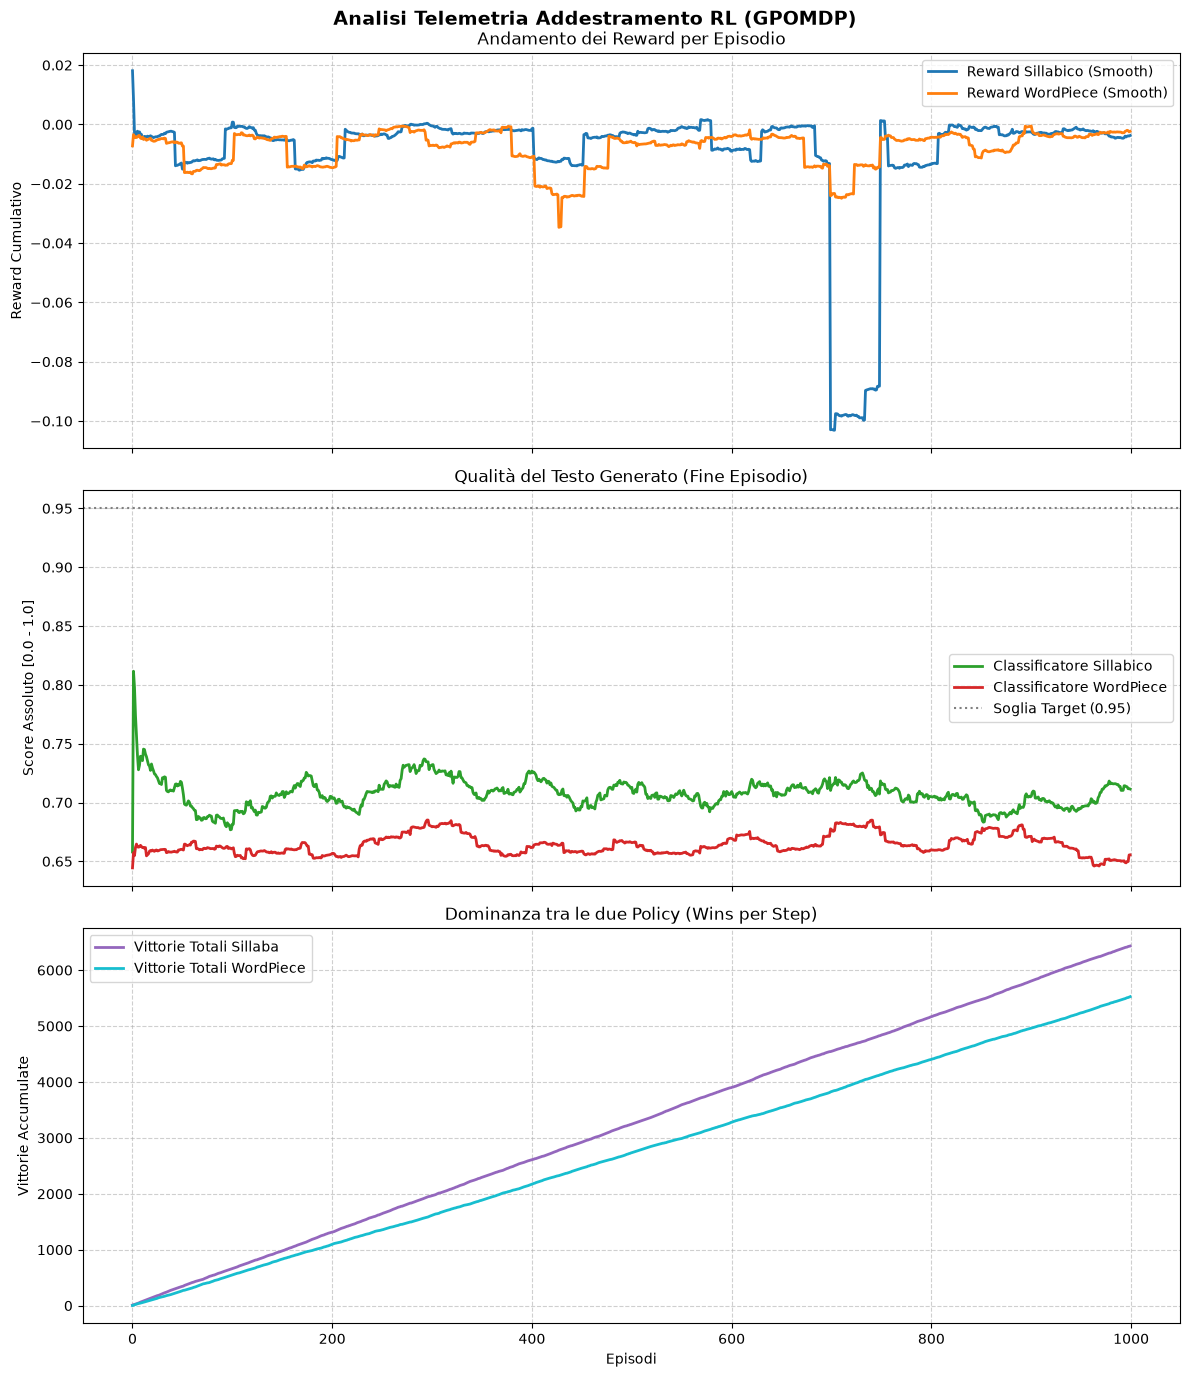

[INFO] Grafici generati e salvati in 'logs/rl_training_analysis.png'


In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd


def plot_rl_training_history(history_path: str = "logs/rl_history.json"):
    # 1. Caricamento del file JSON della storia
    with open(history_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    episodes = data.get("episodes", [])
    if not episodes:
        print(f"[ERROR] Nessun dato trovato in '{history_path}'")
        return

    df = pd.DataFrame(episodes)

    # Estrazione delle metriche aggregate per ogni episodio
    df["syl_reward_sum"] = df["steps"].apply(
        lambda steps: sum(s.get("reward_syl", 0.0) for s in steps)
    )
    df["word_reward_sum"] = df["steps"].apply(
        lambda steps: sum(s.get("reward_word", 0.0) for s in steps)
    )

    df["final_syl_score"] = df["steps"].apply(
        lambda steps: (
            steps[-1].get("syl_classifier_score", 0.0) if steps else 0.0
        )
    )
    df["final_word_score"] = df["steps"].apply(
        lambda steps: (
            steps[-1].get("word_classifier_score", 0.0) if steps else 0.0
        )
    )

    # Media mobile (Smoothing) per pulire il rumore visivo
    window = max(1, len(df) // 20)
    df["syl_reward_smooth"] = (
        df["syl_reward_sum"].rolling(window, min_periods=1).mean()
    )
    df["word_reward_smooth"] = (
        df["word_reward_sum"].rolling(window, min_periods=1).mean()
    )
    df["syl_score_smooth"] = (
        df["final_syl_score"].rolling(window, min_periods=1).mean()
    )
    df["word_score_smooth"] = (
        df["final_word_score"].rolling(window, min_periods=1).mean()
    )

    # 2. Creazione del Layout dei Grafici
    fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
    fig.suptitle("Analisi Telemetria Addestramento RL (GPOMDP)", fontsize=14, fontweight="bold")

    # --- GRAFICO 1: Reward Medi per Episodio ---
    axes[0].plot(
        df["syl_reward_smooth"],
        label="Reward Sillabico (Smooth)",
        color="tab:blue",
        linewidth=2,
    )
    axes[0].plot(
        df["word_reward_smooth"],
        label="Reward WordPiece (Smooth)",
        color="tab:orange",
        linewidth=2,
    )
    axes[0].set_ylabel("Reward Cumulativo")
    axes[0].set_title("Andamento dei Reward per Episodio")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    # --- GRAFICO 2: Punteggi Assoluti dei Classificatori a Fine Episodio ---
    axes[1].plot(
        df["syl_score_smooth"],
        label="Classificatore Sillabico",
        color="tab:green",
        linewidth=2,
    )
    axes[1].plot(
        df["word_score_smooth"],
        label="Classificatore WordPiece",
        color="tab:red",
        linewidth=2,
    )
    axes[1].axhline(
        y=0.95,
        color="gray",
        linestyle=":",
        label="Soglia Target (0.95)",
    )
    axes[1].set_ylabel("Score Assoluto [0.0 - 1.0]")
    axes[1].set_title("Qualità del Testo Generato (Fine Episodio)")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].legend()

    # --- GRAFICO 3: Rapporto di Vittorie (Wins Cumulative) ---
    df["word_wins_cum"] = df["word_win_count"].cumsum()
    df["syl_wins_cum"] = df["syl_win_count"].cumsum()

    axes[2].plot(
        df["syl_wins_cum"],
        label="Vittorie Totali Sillaba",
        color="tab:purple",
        linewidth=2,
    )
    axes[2].plot(
        df["word_wins_cum"],
        label="Vittorie Totali WordPiece",
        color="tab:cyan",
        linewidth=2,
    )
    axes[2].set_xlabel("Episodi")
    axes[2].set_ylabel("Vittorie Accumulate")
    axes[2].set_title("Dominanza tra le due Policy (Wins per Step)")
    axes[2].grid(True, linestyle="--", alpha=0.6)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("logs/rl_training_analysis.png", dpi=300)
    plt.show()
    print("[INFO] Grafici generati e salvati in 'logs/rl_training_analysis.png'")


if __name__ == "__main__":
    plot_rl_training_history("logs/training_history_rhymes_end_focused_corruption.pt")